# 🚀 OnePilot — Forecasting | Notebook 6 : Intégration
**Objectif** : Consolider tout en une fonction `forecast()` prête pour `forecast_agent.py`  
**Fix** : correction du bug NaN dans les prévisions SARIMA  
**Output** : code final copy-pasteable

In [1]:
import requests, json
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import logging, warnings
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

BASE_URL   = 'http://onepilot_api:8000'
SOURCE_NW  = '3896cf72-00e3-4528-8fd5-e65395be8d5f'
SOURCE_SXA = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'
device     = 'cuda' if torch.cuda.is_available() else 'cpu'

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})
print('✅ Imports OK')

✅ Imports OK


In [2]:
# ══════════════════════════════════════════════════════════════════
# ARCHITECTURE LSTM
# ══════════════════════════════════════════════════════════════════
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

print('✅ LSTMForecaster défini')

✅ LSTMForecaster défini


In [8]:
def run_sql(sql, source_id=SOURCE_NW, limit=10000):
    resp = requests.post(f'{BASE_URL}/dashboard/data',
                         json={'sql': sql, 'source_id': source_id, 'limit': limit},
                         timeout=60)
    data = resp.json()
    if 'rows' not in data:
        raise Exception(f'API error: {data}')
    return pd.DataFrame(data['rows'])

def get_time_series(source_id, entity='revenu', granularity='weekly'):
    """Charge depuis les CSV existants (déjà extraits en NB1)."""
    if granularity == 'monthly':
        df = pd.read_csv('/tmp/northwind_monthly.csv', index_col='date', parse_dates=True)
        freq = 'MS'
    else:
        df = pd.read_csv('/tmp/northwind_weekly.csv', index_col='date', parse_dates=True)
        freq = 'W'
    df['revenu'] = pd.to_numeric(df['revenu'])
    return df['revenu'], freq

def train_test_split_ts(series, test_ratio=0.2):
    split = int(len(series) * (1 - test_ratio))
    return series.iloc[:split], series.iloc[split:]

print('✅ Helpers définis (chargement CSV local)')

✅ Helpers définis (chargement CSV local)


In [9]:
# ══════════════════════════════════════════════════════════════════
# FONCTION PRINCIPALE : forecast()
# ══════════════════════════════════════════════════════════════════

def forecast(source_id, horizon=12, granularity='weekly', verbose=True):
    """
    Pipeline complet de forecasting OnePilot.
    
    Params:
        source_id   : UUID de la source ERP
        horizon     : nombre de périodes à prévoir
        granularity : 'weekly' ou 'monthly'
        verbose     : afficher les étapes
    
    Returns:
        dict avec :
          - best_model  : nom du meilleur modèle
          - mae         : MAE sur validation
          - forecast_df : DataFrame avec forecast + IC 95%
          - ranking     : classement 7 combinaisons
          - history     : série historique complète
    """
    WINDOW = 8

    # ── 1. Extraction données ─────────────────────────────────────
    if verbose: print('📊 Extraction des données...')
    series, freq = get_time_series(source_id, granularity=granularity)
    train, test  = train_test_split_ts(series)
    n_test       = len(test)
    n_total      = n_test + horizon
    if verbose:
        print(f'   {len(series)} points | train={len(train)} | test={n_test}')

    # ── 2. SARIMA ─────────────────────────────────────────────────
    if verbose: print('1️⃣  SARIMA...')
    m = 52 if granularity == 'weekly' else 12
    sarima_m = auto_arima(train, seasonal=True, m=m, stepwise=True,
                           max_p=2, max_q=2, max_P=1, max_Q=1,
                           suppress_warnings=True, error_action='ignore', trace=False)
    sarima_fc_arr, sarima_ci = sarima_m.predict(n_periods=n_total, return_conf_int=True)
    sarima_fc_arr = np.clip(sarima_fc_arr, 0, None)
    if verbose: print(f'   SARIMA{sarima_m.order} — MAE: {mean_absolute_error(test, sarima_fc_arr[:n_test]):,.0f}€')

    # ── 3. Prophet ────────────────────────────────────────────────
    if verbose: print('2️⃣  Prophet...')
    df_p = pd.DataFrame({'ds': train.index, 'y': train.values})
    prophet_m = Prophet(yearly_seasonality=(len(train) >= 52),
                        weekly_seasonality=(granularity == 'weekly'),
                        daily_seasonality=False,
                        changepoint_prior_scale=0.3, interval_width=0.95)
    prophet_m.fit(df_p)
    future_p  = prophet_m.make_future_dataframe(periods=n_total, freq=freq)
    fc_p      = prophet_m.predict(future_p)
    fc_p_fut  = fc_p[fc_p['ds'] > train.index[-1]].head(n_total)
    prophet_fc_arr = np.clip(fc_p_fut['yhat'].values,       0, None)
    prophet_lo_arr = np.clip(fc_p_fut['yhat_lower'].values, 0, None)
    prophet_hi_arr = fc_p_fut['yhat_upper'].values
    if verbose: print(f'   Prophet — MAE: {mean_absolute_error(test, prophet_fc_arr[:n_test]):,.0f}€')

    # ── 4. LSTM ───────────────────────────────────────────────────
    if verbose: print('3️⃣  LSTM...')
    scaler_lstm = MinMaxScaler()
    train_sc = scaler_lstm.fit_transform(train.values.reshape(-1,1)).flatten()
    # Séquences
    X_lst, y_lst = [], []
    for i in range(len(train_sc) - WINDOW):
        X_lst.append(train_sc[i:i+WINDOW])
        y_lst.append(train_sc[i+WINDOW])
    X_t = torch.FloatTensor(np.array(X_lst)).unsqueeze(-1).to(device)
    y_t = torch.FloatTensor(np.array(y_lst)).to(device)
    # Entraînement
    lstm_m  = LSTMForecaster().to(device)
    opt     = torch.optim.Adam(lstm_m.parameters(), lr=0.001)
    crit    = nn.MSELoss()
    loader  = torch.utils.data.DataLoader(
                  torch.utils.data.TensorDataset(X_t, y_t), batch_size=16, shuffle=True)
    for epoch in range(100):
        lstm_m.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = crit(lstm_m(xb), yb); loss.backward(); opt.step()
    # Prévision
    lstm_m.eval()
    win = list(train_sc[-WINDOW:])
    preds_sc = []
    with torch.no_grad():
        for _ in range(n_total):
            x_in = torch.FloatTensor(win[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
            pred = lstm_m(x_in).item()
            preds_sc.append(pred); win.append(pred)
    lstm_fc_arr = scaler_lstm.inverse_transform(
                      np.clip(preds_sc, 0, 1).reshape(-1,1)).flatten()
    lstm_fc_arr = np.clip(lstm_fc_arr, 0, None)
    if verbose: print(f'   LSTM — MAE: {mean_absolute_error(test, lstm_fc_arr[:n_test]):,.0f}€')

    # ── 5. Ensemble 7 combinaisons ────────────────────────────────
    if verbose: print('🏆 Sélection du meilleur ensemble...')
    s = sarima_fc_arr[:n_test]
    p = prophet_fc_arr[:n_test]
    l = lstm_fc_arr[:n_test]
    y = test.values
    combos = {
        'SARIMA':              s,
        'Prophet':             p,
        'LSTM':                l,
        'SARIMA+Prophet':      (s+p)/2,
        'SARIMA+LSTM':         (s+l)/2,
        'Prophet+LSTM':        (p+l)/2,
        'SARIMA+Prophet+LSTM': (s+p+l)/3,
    }
    maes = {k: mean_absolute_error(y, v) for k, v in combos.items()}
    best_name = min(maes, key=maes.get)
    best_mae  = maes[best_name]

    # Ranking
    ranking = pd.DataFrame([
        {'modele': k, 'mae': v, 'mae_fmt': f'{v:,.0f}€'}
        for k, v in sorted(maes.items(), key=lambda x: x[1])
    ])

    # ── 6. Prévisions finales ─────────────────────────────────────
    models_in = best_name.split('+')
    fc_arrays = []
    lo_arrays, hi_arrays = [], []
    if 'SARIMA'  in models_in:
        fc_arrays.append(sarima_fc_arr)
        lo_arrays.append(np.clip(sarima_ci[:,0], 0, None))
        hi_arrays.append(sarima_ci[:,1])
    if 'Prophet' in models_in:
        fc_arrays.append(prophet_fc_arr)
        lo_arrays.append(prophet_lo_arr)
        hi_arrays.append(prophet_hi_arr)
    if 'LSTM'    in models_in:
        fc_arrays.append(lstm_fc_arr)
        lo_arrays.append(lstm_fc_arr * 0.85)
        hi_arrays.append(lstm_fc_arr * 1.15)

    best_fc = np.mean(fc_arrays, axis=0)
    best_lo = np.mean(lo_arrays, axis=0)
    best_hi = np.mean(hi_arrays, axis=0)

    future_idx = pd.date_range(
        start=train.index[-1] + pd.Timedelta(weeks=1 if granularity=='weekly' else 31),
        periods=n_total, freq=freq
    )
    forecast_df = pd.DataFrame({
        'forecast': best_fc,
        'lower_95': best_lo,
        'upper_95': best_hi
    }, index=future_idx)

    if verbose:
        print(f'\n✅ Meilleur modèle : {best_name} — MAE: {best_mae:,.0f}€')

    return {
        'best_model':  best_name,
        'mae':         best_mae,
        'forecast_df': forecast_df,
        'ranking':     ranking,
        'history':     series,
        'test':        test,
        'granularity': granularity,
        'freq':        freq
    }

print('✅ Fonction forecast() définie')

✅ Fonction forecast() définie


In [10]:
# ══════════════════════════════════════════════════════════════════
# TEST FINAL — Northwind hebdomadaire
# ══════════════════════════════════════════════════════════════════
print('🚀 Test forecast() sur Northwind hebdomadaire\n')
result = forecast(SOURCE_NW, horizon=12, granularity='weekly', verbose=True)

print('\n📊 Classement 7 combinaisons :')
for _, row in result['ranking'].iterrows():
    badge = ' ✅ SÉLECTIONNÉ' if row['modele'] == result['best_model'] else ''
    print(f"   {row['modele']:<25} {row['mae_fmt']}{badge}")

🚀 Test forecast() sur Northwind hebdomadaire

📊 Extraction des données...
   99 points | train=79 | test=20
1️⃣  SARIMA...


23:22:53 - cmdstanpy - INFO - Chain [1] start processing
23:22:53 - cmdstanpy - INFO - Chain [1] done processing


   SARIMA(0, 1, 1) — MAE: 10,463€
2️⃣  Prophet...
   Prophet — MAE: 15,954€
3️⃣  LSTM...
   LSTM — MAE: 11,817€
🏆 Sélection du meilleur ensemble...

✅ Meilleur modèle : SARIMA — MAE: 10,463€

📊 Classement 7 combinaisons :
   SARIMA                    10,463€ ✅ SÉLECTIONNÉ
   SARIMA+LSTM               11,101€
   LSTM                      11,817€
   SARIMA+Prophet+LSTM       12,719€
   SARIMA+Prophet            13,170€
   Prophet+LSTM              13,886€
   Prophet                   15,954€


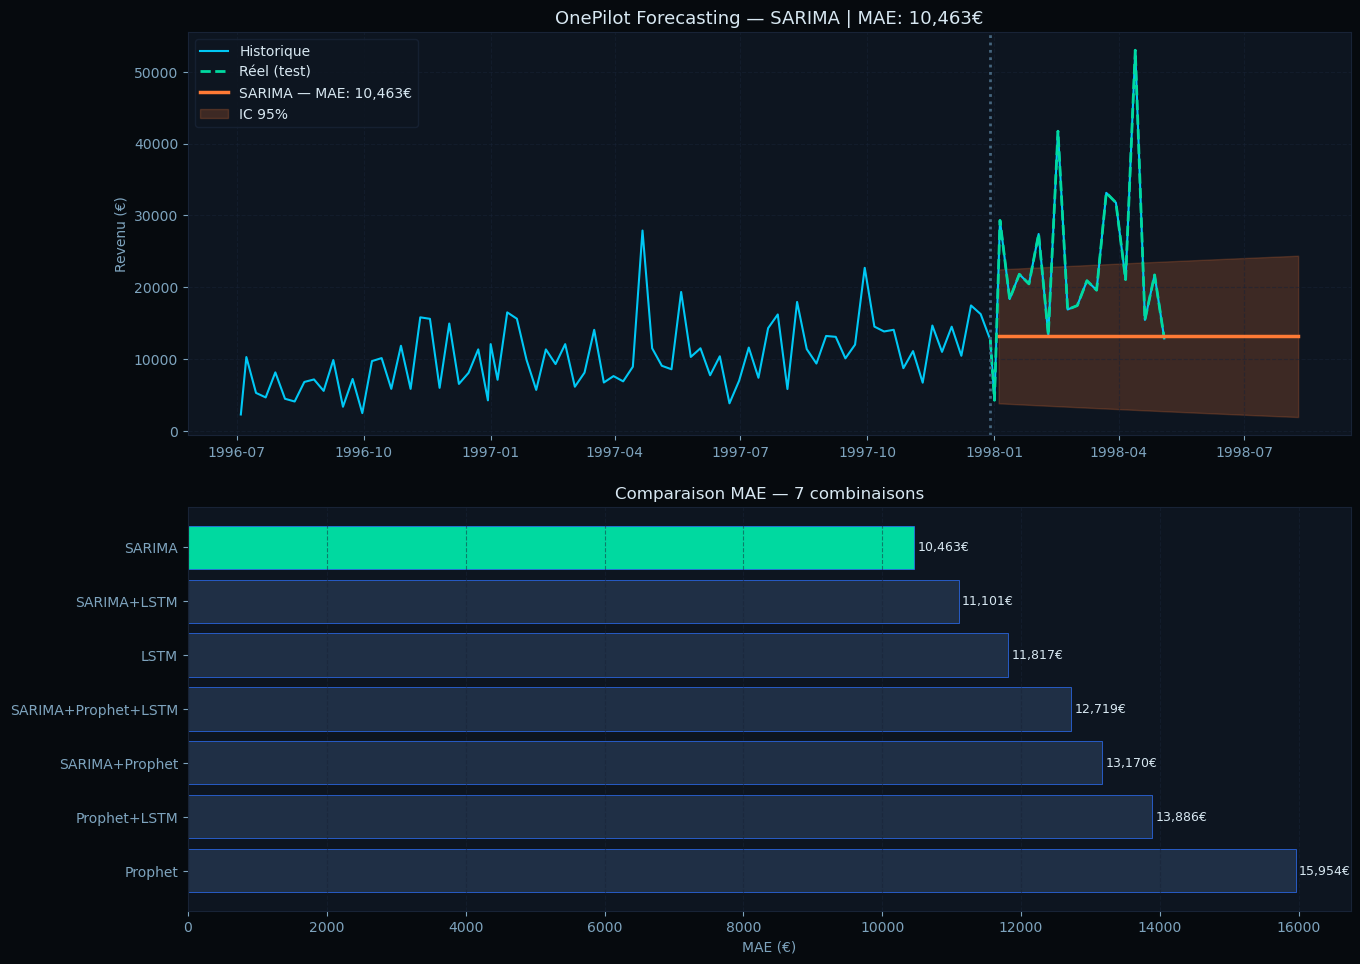

✅ Graphique final sauvegardé → /tmp/forecast_final.png


In [11]:
# ══════════════════════════════════════════════════════════════════
# VISUALISATION FINALE
# ══════════════════════════════════════════════════════════════════
res = result
fc  = res['forecast_df']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 — Prévision
ax1 = axes[0]
ax1.plot(res['history'].index, res['history'].values,
         color='#00c8f5', lw=1.5, label='Historique')
ax1.plot(res['test'].index, res['test'].values,
         color='#00d9a0', lw=2, linestyle='--', label='Réel (test)')
ax1.plot(fc.index, fc['forecast'],
         color='#ff7a35', lw=2.5,
         label=f"{res['best_model']} — MAE: {res['mae']:,.0f}€")
ax1.fill_between(fc.index, fc['lower_95'], fc['upper_95'],
                 alpha=0.2, color='#ff7a35', label='IC 95%')
ax1.axvline(x=res['test'].index[0], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f"OnePilot Forecasting — {res['best_model']} | MAE: {res['mae']:,.0f}€",
              color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Revenu (€)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# Graphique 2 — Classement MAE
ax2 = axes[1]
colors = ['#00d9a0' if r['modele'] == res['best_model'] else '#1f2f45'
          for _, r in res['ranking'].iterrows()]
bars = ax2.barh(res['ranking']['modele'], res['ranking']['mae'],
                color=colors, edgecolor='#2d72ff', lw=0.5)
for bar, (_, row) in zip(bars, res['ranking'].iterrows()):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             row['mae_fmt'], va='center', color='#d8e8f2', fontsize=9)
ax2.set_title('Comparaison MAE — 7 combinaisons', color='#d8e8f2', fontsize=12)
ax2.set_xlabel('MAE (€)', color='#7ea4be')
ax2.grid(True, axis='x')
ax2.invert_yaxis()

plt.tight_layout(pad=2)
plt.savefig('/tmp/forecast_final.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique final sauvegardé → /tmp/forecast_final.png')

In [12]:
# ══════════════════════════════════════════════════════════════════
# RÉSUMÉ — PRÊT POUR forecast_agent.py
# ══════════════════════════════════════════════════════════════════
print('='*55)
print('  RÉSUMÉ FINAL — NOTEBOOKS FORECASTING')
print('='*55)
print()
print('  NB1 → Pipeline données       ✅')
print('  NB2 → SARIMA mensuel         ✅  MAE ~40k€')
print('  NB3 → Prophet mensuel        ✅  MAE ~42k€')
print('  NB4 → LSTM hebdo             ✅  MAE ~12k€')
print('  NB5 → Ensemble comparatif    ✅  SARIMA gagne')
print('  NB6 → Fonction intégrée      ✅  forecast() prête')
print()
print(f'  Meilleur modèle  : {result["best_model"]}')
print(f'  MAE final        : {result["mae"]:,.0f} €')
print()
print('  → Prochaine étape : créer forecast_agent.py')
print('    et ajouter endpoint /forecast dans main.py')

  RÉSUMÉ FINAL — NOTEBOOKS FORECASTING

  NB1 → Pipeline données       ✅
  NB2 → SARIMA mensuel         ✅  MAE ~40k€
  NB3 → Prophet mensuel        ✅  MAE ~42k€
  NB4 → LSTM hebdo             ✅  MAE ~12k€
  NB5 → Ensemble comparatif    ✅  SARIMA gagne
  NB6 → Fonction intégrée      ✅  forecast() prête

  Meilleur modèle  : SARIMA
  MAE final        : 10,463 €

  → Prochaine étape : créer forecast_agent.py
    et ajouter endpoint /forecast dans main.py


In [13]:
import requests
BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'

def run_sql(sql, source_id, limit=100):
    resp = requests.post(f'{BASE_URL}/dashboard/data',
                         json={'sql': sql, 'source_id': source_id, 'limit': limit},
                         timeout=60)
    return __import__('pandas').DataFrame(resp.json().get('rows', []))

# 1. Lister les vues et tables SXA
df_tables = run_sql("""
    SELECT TABLE_NAME, TABLE_TYPE
    FROM INFORMATION_SCHEMA.TABLES
    ORDER BY TABLE_TYPE, TABLE_NAME
""", SOURCE_SXA)
print(f'Tables/Vues SXA ({len(df_tables)}) :')
print(df_tables.to_string(index=False))

Tables/Vues SXA (0) :
Empty DataFrame
Columns: []
Index: []


In [14]:
# Tester les vues SXA connues
vues_sxa = [
    'SI_Trésorerie', 'Dernière integration bancaire',
    'FINANCEMENT_BI', 'Journal', 'Comptes',
    'Transactions bancaires', 'GS_CUR'
]

for vue in vues_sxa:
    try:
        df = run_sql(f"SELECT TOP 3 * FROM [{vue}]", SOURCE_SXA, limit=3)
        print(f'✅ [{vue}] — {len(df.columns)} colonnes : {list(df.columns)}')
    except Exception as e:
        print(f'❌ [{vue}] — {str(e)[:60]}')

✅ [SI_Trésorerie] — 0 colonnes : []
✅ [Dernière integration bancaire] — 0 colonnes : []
✅ [FINANCEMENT_BI] — 0 colonnes : []
✅ [Journal] — 0 colonnes : []
✅ [Comptes] — 0 colonnes : []
✅ [Transactions bancaires] — 0 colonnes : []
✅ [GS_CUR] — 0 colonnes : []


In [15]:
import requests, json

BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'

# Voir la réponse brute
resp = requests.post(f'{BASE_URL}/dashboard/data',
    json={'sql': "SELECT TOP 5 * FROM [SI_Trésorerie]",
          'source_id': SOURCE_SXA, 'limit': 5},
    timeout=60)

raw = resp.json()
print('Status  :', resp.status_code)
print('Clés    :', list(raw.keys()))
print('Colonnes:', raw.get('columns', []))
print('Count   :', raw.get('count', 0))
print('Rows[0] :', raw.get('rows', [{}])[0] if raw.get('rows') else 'VIDE')

Status  : 500
Clés    : ['detail']
Colonnes: []
Count   : 0
Rows[0] : VIDE


In [16]:
resp = requests.post(f'{BASE_URL}/dashboard/data',
    json={'sql': "SELECT TOP 5 * FROM [SI_Trésorerie]",
          'source_id': SOURCE_SXA, 'limit': 5},
    timeout=60)

print(resp.json()['detail'])

('HYT00', '[HYT00] [Microsoft][ODBC Driver 18 for SQL Server]Login timeout expired (0) (SQLDriverConnect)')


In [1]:
import requests
BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'

resp = requests.post(f'{BASE_URL}/dashboard/data',
    json={'sql': "SELECT TOP 3 * FROM [SI_Trésorerie]",
          'source_id': SOURCE_SXA, 'limit': 3},
    timeout=60)
print(resp.json())

{'rows': [{'CODE': 'BNP Paribas Agence Centrale Compte 4', 'DESCRIPTION': 'BNP Paribas Agence Centrale Compte 4', 'Banque': 'BNP Paribas', 'Société': 'SAGE', 'AMOUNTI': -100147.167, 'ISDEBITI': True, 'TRNDATE': '2023-12-31', 'Groupe_Sociétés': None, 'Description_groupe_de_sociétés': None}, {'CODE': 'BNP Paribas Agence Centrale Compte 3', 'DESCRIPTION': 'BNP Paribas Agence Centrale Compte 3', 'Banque': 'BNP Paribas', 'Société': 'SAGE', 'AMOUNTI': 200.148, 'ISDEBITI': False, 'TRNDATE': '2023-12-31', 'Groupe_Sociétés': None, 'Description_groupe_de_sociétés': None}, {'CODE': 'BNP Paribas Agence Centrale Compte 1', 'DESCRIPTION': 'BNP Paribas Agence Centrale Compte 1', 'Banque': 'BNP Paribas', 'Société': 'SAGE', 'AMOUNTI': 0.0, 'ISDEBITI': False, 'TRNDATE': '2023-12-31', 'Groupe_Sociétés': None, 'Description_groupe_de_sociétés': None}], 'columns': ['CODE', 'DESCRIPTION', 'Banque', 'Société', 'AMOUNTI', 'ISDEBITI', 'TRNDATE', 'Groupe_Sociétés', 'Description_groupe_de_sociétés'], 'count': 3}


In [3]:
import requests, pandas as pd

BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'

def run_sql(sql, source_id, limit=10000):
    resp = requests.post(f'{BASE_URL}/dashboard/data',
                         json={'sql': sql, 'source_id': source_id, 'limit': limit},
                         timeout=60)
    data = resp.json()
    if 'rows' not in data:
        raise Exception(data)
    return pd.DataFrame(data['rows'])

# 1. Dates disponibles
df1 = run_sql("SELECT COUNT(DISTINCT TRNDATE) as nb_dates, MIN(TRNDATE) as debut, MAX(TRNDATE) as fin FROM [SI_Trésorerie]", SOURCE_SXA)
print("Dates :", df1.to_string(index=False))

# 2. Série temporelle
df2 = run_sql("""
    SELECT TRNDATE,
           SUM(CASE WHEN ISDEBITI=0 THEN AMOUNTI ELSE -AMOUNTI END) AS solde_net,
           COUNT(*) AS nb_transactions
    FROM [SI_Trésorerie]
    GROUP BY TRNDATE ORDER BY TRNDATE
""", SOURCE_SXA)
print(f"\nPoints : {len(df2)}")
print(df2.to_string(index=False))

Dates :  nb_dates      debut        fin
        1 2023-12-31 2023-12-31

Points : 1
   TRNDATE  solde_net  nb_transactions
2023-12-31 398236.189                6


In [4]:
for vue in ['Transactions bancaires', 'Journal', 'FINANCEMENT_BI', 'Dernière integration bancaire']:
    try:
        df = run_sql(f"""
            SELECT COUNT(*) as nb_lignes,
                   COUNT(DISTINCT CAST(TRNDATE AS DATE)) as nb_dates,
                   MIN(CAST(TRNDATE AS DATE)) as debut,
                   MAX(CAST(TRNDATE AS DATE)) as fin
            FROM [{vue}]
        """, SOURCE_SXA)
        print(f"✅ [{vue}]")
        print(f"   {df.to_string(index=False)}\n")
    except Exception as e:
        # Chercher la colonne date automatiquement
        try:
            df_cols = run_sql(f"SELECT TOP 1 * FROM [{vue}]", SOURCE_SXA, limit=1)
            print(f"⚠️  [{vue}] — colonnes : {list(df_cols.columns)}\n")
        except Exception as e2:
            print(f"❌ [{vue}] — {str(e2)[:60]}\n")

✅ [Transactions bancaires]
    nb_lignes  nb_dates      debut        fin
      9446       366 2024-01-02 2025-06-20

⚠️  [Journal] — colonnes : ['CODE', 'DESCRIPTION', 'Sous_Catégorie_flux', 'Catégorie_flux', 'Montant ABS', 'ISDEBIT', 'Date de transaction', 'date de valeur', 'Statut', 'Montant_avec_signe', 'Code_budget', 'Description_budget', 'Catégorie_budget', 'Compte', 'Description_compte', 'Banque', 'Société', 'Devise du compte', 'Groupe_Sociétés', 'Description_groupe_de_sociétés', 'Groupe_de_comptes']

⚠️  [FINANCEMENT_BI] — colonnes : ['TRN_ID', 'GNRLSTATUS', 'Date début', 'Date fin', 'Montant', 'PRPCNTRVAMOUNT', 'FINLINE_DTLS_ID', 'Devises  financement', 'type_transaction', 'PRPFINLINERATE', 'maturité', 'type', 'état', 'compte', 'description_compte', 'Banque', 'Société', 'RNGDATE', 'Devises du compte', 'SUBCATEGORY', 'Groupe_Sociétés', 'Description_groupe_de_sociétés', 'Groupe_de_comptes']

⚠️  [Dernière integration bancaire] — colonnes : ['CODE', 'Banque', 'Société', 'Devises',

In [5]:
# Colonnes de Transactions bancaires
df_cols = run_sql("SELECT TOP 3 * FROM [Transactions bancaires]", SOURCE_SXA, limit=3)
print("Colonnes :", list(df_cols.columns))
print()
print(df_cols.to_string(index=False))

Colonnes : ['CODE', 'DESCRIPTION', 'Banque', 'Société', 'AMOUNT', 'montant avec signe', 'CUR_ID_TRNCURRENCY', 'TRNDATE', 'VALUEDATE', 'ISDEBIT', 'Statut', 'Groupe_Sociétés', 'Description_groupe_de_sociétés', 'Groupe_de_comptes']

                                CODE                          DESCRIPTION      Banque Société  AMOUNT  montant avec signe CUR_ID_TRNCURRENCY    TRNDATE  VALUEDATE  ISDEBIT      Statut Groupe_Sociétés Description_groupe_de_sociétés Groupe_de_comptes
BNP Paribas Agence Centrale Compte 4 BNP Paribas Agence Centrale Compte 4 BNP Paribas    SAGE     3.8                -3.8                TND 2024-01-02 2024-01-02     True Rapprochées            None                           None              None
BNP Paribas Agence Centrale Compte 4 BNP Paribas Agence Centrale Compte 4 BNP Paribas    SAGE    20.0               -20.0                TND 2024-01-02 2024-01-02     True Rapprochées            None                           None              None
BNP Paribas Agence Cent

In [6]:
df_weekly = run_sql("""
    SELECT 
        YEAR(TRNDATE) AS annee,
        DATEPART(WEEK, TRNDATE) AS semaine,
        MIN(TRNDATE) AS date_debut,
        SUM([montant avec signe]) AS flux_net,
        SUM(CASE WHEN ISDEBIT=0 THEN AMOUNT ELSE 0 END) AS entrees,
        SUM(CASE WHEN ISDEBIT=1 THEN AMOUNT ELSE 0 END) AS sorties,
        COUNT(*) AS nb_transactions
    FROM [Transactions bancaires]
    GROUP BY YEAR(TRNDATE), DATEPART(WEEK, TRNDATE)
    ORDER BY annee, semaine
""", SOURCE_SXA)

print(f"✅ Série hebdomadaire SXA : {len(df_weekly)} semaines")
print(f"   Période : {df_weekly['date_debut'].min()} → {df_weekly['date_debut'].max()}")
print(f"   Flux net moyen : {df_weekly['flux_net'].mean():,.0f} TND")
print(f"   Min : {df_weekly['flux_net'].min():,.0f} TND")
print(f"   Max : {df_weekly['flux_net'].max():,.0f} TND")
print()
print(df_weekly.head(5).to_string(index=False))

✅ Série hebdomadaire SXA : 78 semaines
   Période : 2024-01-02 → 2025-06-16
   Flux net moyen : -8,615 TND
   Min : -432,243 TND
   Max : 354,857 TND

 annee  semaine date_debut   flux_net    entrees    sorties  nb_transactions
  2024        1 2024-01-02   2370.455 149027.275 146656.820               92
  2024        2 2024-01-08  39089.053 602444.371 563355.318               96
  2024        3 2024-01-15 -75659.804 328066.357 403726.161              104
  2024        4 2024-01-22 -68116.805 303107.488 371224.293              117
  2024        5 2024-01-29 -24346.295 259908.633 284254.928              166
